In [1]:
import os
import time
import numpy as np
import scipy as sp
import pandas as pd
#%matplotlib widget
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation as R
from scipy import stats
from scipy.optimize import curve_fit
from collections import namedtuple
#print('np ',np.__version__)
#print('mpl',mpl.__version__)

In [9]:
expr_df = pd.read_csv(r"data\celegan_scaled_expression_matrix.csv", index_col=0)
print("Expr matrix shape (cells × genes):", expr_df.shape)
print("First few columns:", expr_df.columns[:8])
print("First few indices:", expr_df.index[:5])

Expr matrix shape (cells × genes): (86024, 2766)
First few columns: Index(['cutl-24', 'pnc-1', 'R02D3.1', 'T21D12.12', 'T21D12.7', 'cdh-8',
       'M04G7.1', 'inx-18'],
      dtype='object')
First few indices: Index(['AAACCTGAGACAATAC-300.1.1', 'AAACCTGAGGGCTCTC-300.1.1',
       'AAACCTGAGTGCGTGA-300.1.1', 'AAACCTGAGTTGAGTA-300.1.1',
       'AAACCTGCAAGACGTG-300.1.1'],
      dtype='object')


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3, svd_solver='auto', random_state=0)
scores = pca.fit_transform(expr_df.values)   
loadings = pca.components_.T
gene_means = pca.mean_  

In [33]:
genes_of_interest = [
    'C26B9.3', 'C29F5.1', 'C33A12.4', 'C35E7.11', 'C49F8.3', 'C52G5.2',
    'E02A10.3', 'F32D8.7', 'F41F3.3', 'F42G8.19', 'F48D6.4',
    'abu-13', 'arl-3', 'dyf-6', 'egl-21', 'far-1', 'hhat-1', 'hsp-12.2',
    'let-2', 'lpr-4', 'lpr-5', 'lpr-7', 'mig-18', 'mks-2', 'mlt-9', 'mup-2',
    'pgal-1', 'pghm-1', 'ptb-1', 'rgs-3', 'sbt-1', 'spp-13', 'tnt-3',
    'ttn-1', 'unc-15'
]
frob_norms = []

for gene in genes_of_interest:
    # Zero perturbation
    expr_zero = expr_df.copy()
    expr_zero[gene] = 0.0
    expr_zero_centered = expr_zero.values - gene_means
    #
    Z = expr_zero_centered.dot(loadings) 

    # Double perturbation
    expr_dbl = expr_df.copy()
    expr_dbl[gene] = expr_dbl[gene] * 2.0
    expr_dbl_centered = expr_dbl.values - gene_means
    # 
    D = expr_dbl_centered.dot(loadings)

    # Average perturbation & difference
    M  = (D + Z) / 2.0       # shape (N_cells, 3)
    Delta = M - scores       # shape (N_cells, 3)

    frob_norms.append(np.linalg.norm(Delta, ord='fro'))

In [35]:
len(genes_of_interest)

35

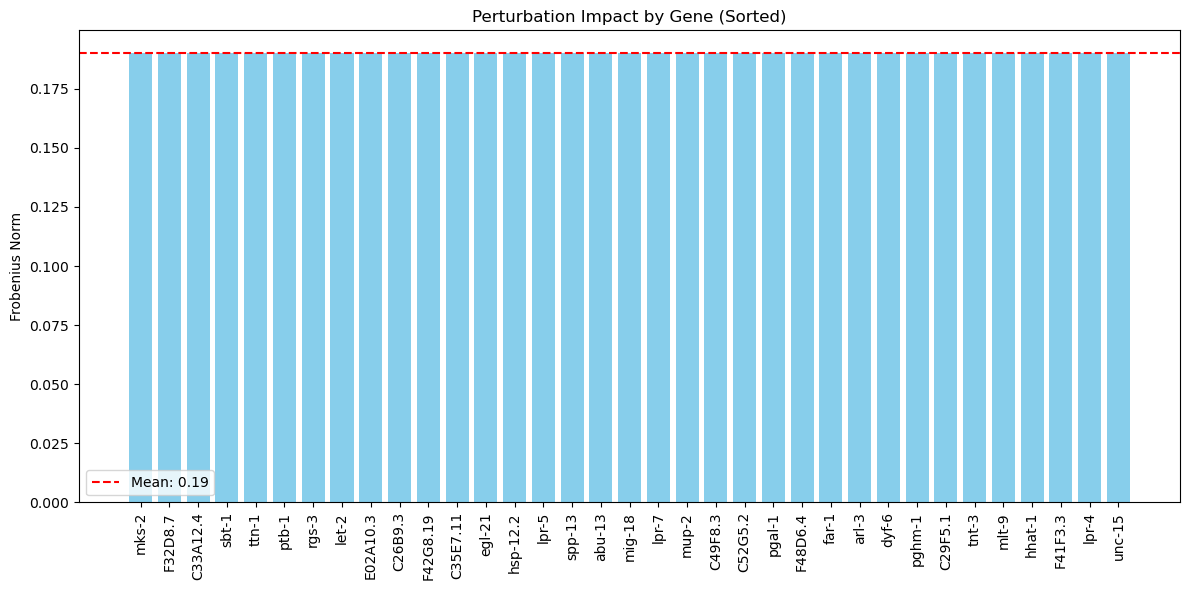

In [34]:
sorted_genes, sorted_norms = zip(*sorted(zip(genes_of_interest, frob_norms), 
                                       key=lambda x: x[1]))

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_genes, sorted_norms, color='skyblue')
plt.axhline(np.mean(frob_norms), color='r', linestyle='--', label=f'Mean: {np.mean(frob_norms):.2f}')
plt.xticks(rotation=90)
plt.ylabel("Frobenius Norm")
plt.title("Perturbation Impact by Gene (Sorted)")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
max_abs_error = np.abs(Delta).max()
mean_abs_error = np.abs(Delta).mean()
print(f"Max absolute error: {max_abs_error:.5e}")
print(f"Mean absolute error: {mean_abs_error:.5e}")

Max absolute error: 4.25987e-03
Mean absolute error: 1.65861e-04


In [23]:
D

array([[ 0.87495241, -5.42193311, -1.74537821],
       [ 1.05704583, -4.98346138,  0.07163825],
       [-3.14578246, -3.93342636,  5.94696374],
       ...,
       [ 8.67379767,  6.57986474,  0.23249109],
       [ 1.59012979, -2.37464743,  0.2506833 ],
       [ 1.11833244, -3.48543616,  0.33872645]])

In [24]:
Z

array([[ 0.87769477, -5.32487434, -1.55951565],
       [ 1.05622503, -5.01251142,  0.01600892],
       [-3.14660326, -3.96247639,  5.89133442],
       ...,
       [ 8.67297687,  6.5508147 ,  0.17686176],
       [ 1.58930899, -2.40369747,  0.19505397],
       [ 1.11751164, -3.5144862 ,  0.28309712]])

In [22]:
scores

array([[ 0.87629362, -5.37338335, -1.65312266],
       [ 1.05662998, -4.9979873 ,  0.04378422],
       [-3.14621797, -3.94794762,  5.91886203],
       ...,
       [ 8.67336536,  6.56534679,  0.2037136 ],
       [ 1.58972297, -2.38917401,  0.22287424],
       [ 1.11791519, -3.49995869,  0.31087639]])

In [2]:
#----------------------------------------------------
# Step 1. read the new data sets with the zero and doubling
#----------------------------------------------------
dbl = pd.read_csv('celegan_dbl_unnormalized_unrotated.csv', delimiter=',')
zer = pd.read_csv('celegan_zero_unnormalized_unrotated.csv', delimiter=',')

import re
genes = np.unique([re.sub('_PC.', '',s) for s in np.array(list(dbl))[1:-5]])
print(genes[9])
print(genes)

F42G8.19
['C26B9.3' 'C29F5.1' 'C33A12.4' 'C35E7.11' 'C49F8.3' 'C52G5.2' 'E02A10.3'
 'F32D8.7' 'F41F3.3' 'F42G8.19' 'F48D6.4' 'PC1' 'PC2' 'PC3' 'T05G5.5'
 'T05H10.3' 'T10B5.4' 'Y44A6D.2' 'abu-13' 'arl-3' 'dyf-6' 'egl-21' 'far-1'
 'hhat-1' 'hsp-12.2' 'let-2' 'lpr-4' 'lpr-5' 'lpr-7' 'mig-18' 'mks-2'
 'mlt-9' 'mup-2' 'pgal-1' 'pghm-1' 'ptb-1' 'rgs-3' 'sbt-1' 'spp-13'
 'tnt-3' 'ttn-1' 'unc-15']


In [7]:
zer.head()

,Unnamed: 0,PC1,PC2,PC3,C26B9.3_PC1,C26B9.3_PC2,C26B9.3_PC3,let-2_PC1,let-2_PC2,let-2_PC3,...,F42G8.19_PC2,F42G8.19_PC3,ptb-1_PC1,ptb-1_PC2,ptb-1_PC3,T06G6.3_PC1,T06G6.3_PC2,T06G6.3_PC3,time,cluster
0,AAACCTGAGACAATAC-300.1.1,-0.833672,5.523125,-1.538245,-0.804905,5.229903,-1.631445,-0.835341,5.204872,-1.554884,...,5.241562,-1.644698,-0.845511,5.241683,-1.646966,-0.839872,5.246937,-1.646874,360.0,330-390
1,AAACCTGAGGGCTCTC-300.1.1,-1.014668,5.146741,0.151730,-0.985902,4.853520,0.058530,-1.014497,4.891473,0.014447,...,4.865178,0.045277,-1.026508,4.865299,0.043009,-1.020869,4.870553,0.043101,240.0,210-270
2,AAACCTGAGTGCGTGA-300.1.1,3.187713,4.096369,6.023817,3.216479,3.803148,5.930617,3.187884,3.841101,5.886534,...,3.814806,5.917364,3.175873,3.814927,5.915096,3.181512,3.820181,5.915188,240.0,210-270
3,AAACCTGAGTTGAGTA-300.1.1,-0.414741,5.438268,1.548349,-0.385975,5.145046,1.455149,-0.414571,5.182999,1.411066,...,5.156705,1.441896,-0.426581,5.156826,1.439628,-0.420942,5.162080,1.439720,300.0,270-330
4,AAACCTGCAAGACGTG-300.1.1,-8.235757,-1.436223,4.650806,-8.206990,-1.729445,4.557606,-8.235586,-1.691492,4.513523,...,-1.717786,4.544353,-8.247596,-1.717665,4.542085,-8.241958,-1.712411,4.542177,360.0,330-390


In [8]:
dbl

,Unnamed: 0,PC1,PC2,PC3,C26B9.3_PC1,C26B9.3_PC2,C26B9.3_PC3,let-2_PC1,let-2_PC2,let-2_PC3,...,F42G8.19_PC2,F42G8.19_PC3,ptb-1_PC1,ptb-1_PC2,ptb-1_PC3,T06G6.3_PC1,T06G6.3_PC2,T06G6.3_PC3,time,cluster
0,AAACCTGAGACAATAC-300.1.1,-0.833672,5.523125,-1.538245,-0.862944,5.276792,-1.664029,-0.832508,5.301823,-1.740590,...,5.265133,-1.650776,-0.822338,5.265012,-1.648508,-0.827977,5.259758,-1.648600,360.0,330-390
1,AAACCTGAGGGCTCTC-300.1.1,-1.014668,5.146741,0.151730,-1.043941,4.900408,0.025946,-1.015345,4.862455,0.070029,...,4.888750,0.039199,-1.003335,4.888629,0.041467,-1.008974,4.883375,0.041375,240.0,210-270
2,AAACCTGAGTGCGTGA-300.1.1,3.187713,4.096369,6.023817,3.158440,3.850036,5.898033,3.187036,3.812083,5.942116,...,3.838377,5.911286,3.199046,3.838256,5.913554,3.193407,3.833003,5.913462,240.0,210-270
3,AAACCTGAGTTGAGTA-300.1.1,-0.414741,5.438268,1.548349,-0.444014,5.191935,1.422565,-0.415418,5.153982,1.466648,...,5.180276,1.435818,-0.403408,5.180155,1.438086,-0.409047,5.174901,1.437994,300.0,270-330
4,AAACCTGCAAGACGTG-300.1.1,-8.235757,-1.436223,4.650806,-8.265030,-1.682556,4.525022,-8.236434,-1.720509,4.569105,...,-1.694215,4.538275,-8.224424,-1.694336,4.540543,-8.230062,-1.699590,4.540451,360.0,330-390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86019,TCTGAGACATGTCGAT-b02,2.991704,1.706811,1.892890,3.175678,1.288201,1.886825,2.991027,1.422525,1.811189,...,1.448819,1.780359,3.003037,1.448698,1.782627,2.997398,1.443444,1.782535,651.0,> 650
86020,TCTGAGACATGTCTCC-b02,-0.657185,2.714831,-2.546836,-0.686457,2.468497,-2.672620,-0.657862,2.430544,-2.628537,...,2.456839,-2.659367,-0.645851,2.456718,-2.657099,-0.651490,2.451464,-2.657191,480.0,450-510
86021,TGGCCAGCACGAAGCA-b02,-8.646301,-6.416731,0.316607,-8.675574,-6.663064,0.190823,-8.646978,-6.701017,0.234906,...,-6.674722,0.204076,-8.634968,-6.674843,0.206344,-8.640607,-6.680097,0.206252,480.0,450-510
86022,TGGCGCACAGGCAGTA-b02,-1.550402,2.539909,0.336666,-1.579675,2.293576,0.210882,-1.551079,2.255623,0.254965,...,2.281918,0.224134,-1.539069,2.281797,0.226402,-1.544708,2.276543,0.226310,360.0,330-390


In [5]:
Q  = dbl[['PC1', 'PC2', 'PC3']].values           # shape (N_cells, 3)
D  = dbl[[f'let-2_PC1', f'let-2_PC2', f'let-2_PC3']].values
Z  = zer[[f'let-2_PC1', f'let-2_PC2', f'let-2_PC3']].values

# 3b) Compute the “average” of doubled+zeroed, then subtract original
M  = (D + Z) / 2.0       # shape (N_cells, 3)
Delta = M - Q           # shape (N_cells, 3)

# 3c) Frobenius norm of the matrix Δ = [Δ_i]^T
#    ‖Δ‖_F = sqrt( sum_{i=1 to N} sum_{j=1 to 3} (Δ_{i,j})^2 )
frob = np.linalg.norm(Delta, ord='fro')
frob

85.39388280445387

In [33]:
#---------------------------------------------------------------
# Step 2. Functions to transform and plot the vector field
#-----------------------------------------------------------------
# create function to convert Cartesian coordinates to angles
#-----------------------------------------------------------------
def XYZ2LatLon(r):
    lat = 90-np.arccos(r[:,2])*180/np.pi
    lon = np.arctan2(r[:,1],r[:,0])*180/np.pi
    return lat,lon

def showVectors(dbl,zer,gene):
    #-------------------------------------------------------------------
    # read the normalized and rotated PCA data for the specific gene
    # q3: original
    # d3: double
    # z3: zero
    #--------------------------------------
    d3 = np.array(dbl[[gene+'_PC1',gene+'_PC2',gene+'_PC3']])
    z3 = np.array(zer[[gene+'_PC1',gene+'_PC2',gene+'_PC3']])
    q3 = np.array(dbl[['PC1','PC2','PC3']])    
    #----------------------------------------------------------
    # subsample randomly the cells where we plot the vector
    # frac is the sampleing fraction
    #----------------------------------------------------------
    frac = 0.015
    ix = np.random.rand(q3[:,0].shape[0]).flatten()< frac
    #-------------------------------------------------------
    # Compute the two displacements from the difference
    # between the double and the zero, and scale it up a bit.
    # Also clip it to avoid very long vectors.
    # w2, w0 are the locations of the end of the vectors, 
    # for dbl, and zero repspectively. There will be a dot 
    # at the original position. BLuish vector is from zero->orig,
    # reddish is orig-> double. 
    #-------------------------------------------------------
    scl = 1.0
    d1 = np.clip(scl*(d3-q3),-0.1,0.1)
    d2 = np.clip(scl*(z3-q3),-0.1,0.1)
    w2 = np.clip(q3 + d1,-1,1)
    w0 = np.clip(q3 - d2,-1,1)
    #-------------------------------------------------
    # compute the lat-lon positions for the Mercator
    # V3 is the original position
    # W3 is the end
    #-------------------------------------------------
    latO3, lonO3 = XYZ2LatLon(q3)
    latQ3, lonQ3 = XYZ2LatLon(q3[ix,:])
    latW0, lonW0 = XYZ2LatLon(w0[ix,:])
    latW2, lonW2 = XYZ2LatLon(w2[ix,:])
    lonW0[lonW0<-185] += 360
    lonW0[lonW0> 185] -= 360
    lonW2[lonW2<-185] += 360
    lonW2[lonW2> 185] -= 360
    nx = latQ3.shape[0]

    #-----------------------------------------
    # plot first all the cells, then the
    # vectors for the random subsample
    #----------------------------------------
    plt.figure(figsize=(16,6))
    plt.title(gene)
    plt.plot(lonO3,latO3,'.c',markersize=0.5,alpha=0.5)
    for n in range(nx):
        plt.plot([lonQ3[n],lonW0[n]],[latQ3[n],latW0[n]],'-',color='#2222CC',lw=1,alpha=0.7, label='Zeroed - Original' if n==0 else "")
        plt.plot([lonQ3[n],lonW2[n]],[latQ3[n],latW2[n]],'-',color='#CC2222',lw=1,alpha=0.7, label='Original - Doubled' if n==0 else "")
        plt.plot(lonQ3[n],latQ3[n],'.k',markersize=2, alpha=0.5)
    plt.xlim(-185,185)
    plt.ylim(-90,90)
    plt.xlabel('Longitude (°)', fontsize=10)  
    plt.ylabel('Latitude (°)', fontsize=10)  
    plt.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),  # (x, y) position relative to the axes
    fontsize=9,
    frameon=False
)
    plt.savefig('Plot/Vector_plot/vector-'+gene+'-2D.png', dpi=600)
    #plt.show()
    

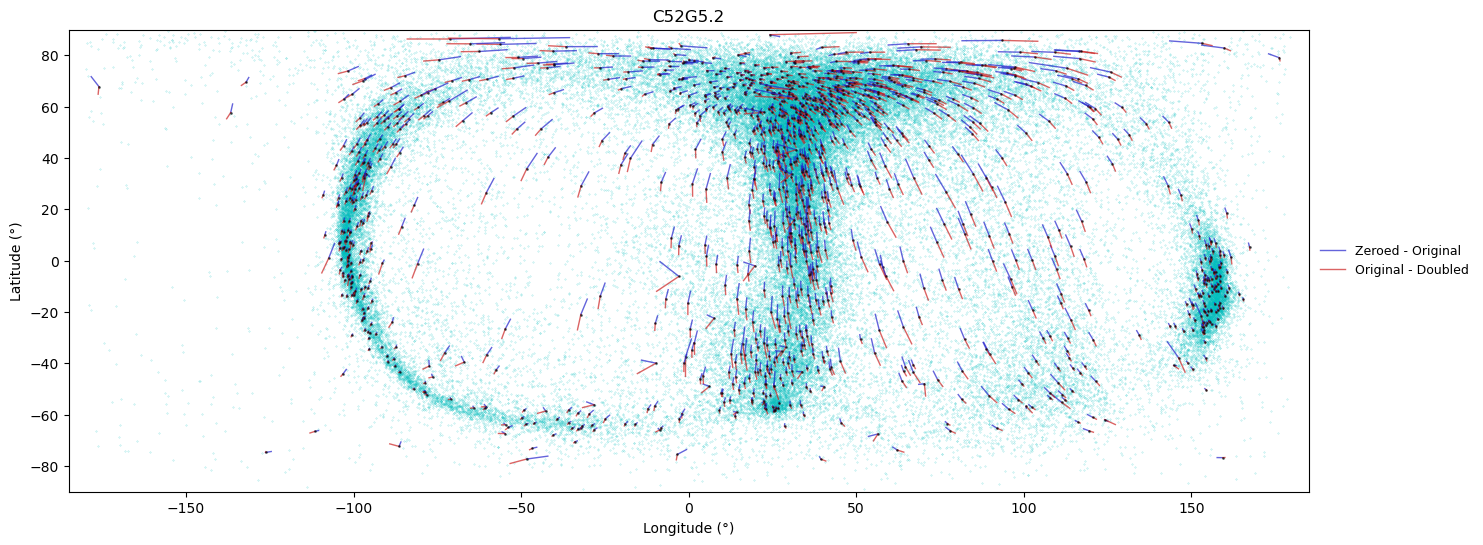

In [31]:
# test it once
showVectors(dbl,zer,genes[5])

In [ ]:
#------------------------------------------------
# Step 3. Run the function for a particular gene
#------------------------------------------------
for g in genes:
    showVectors(dbl,zer,g)

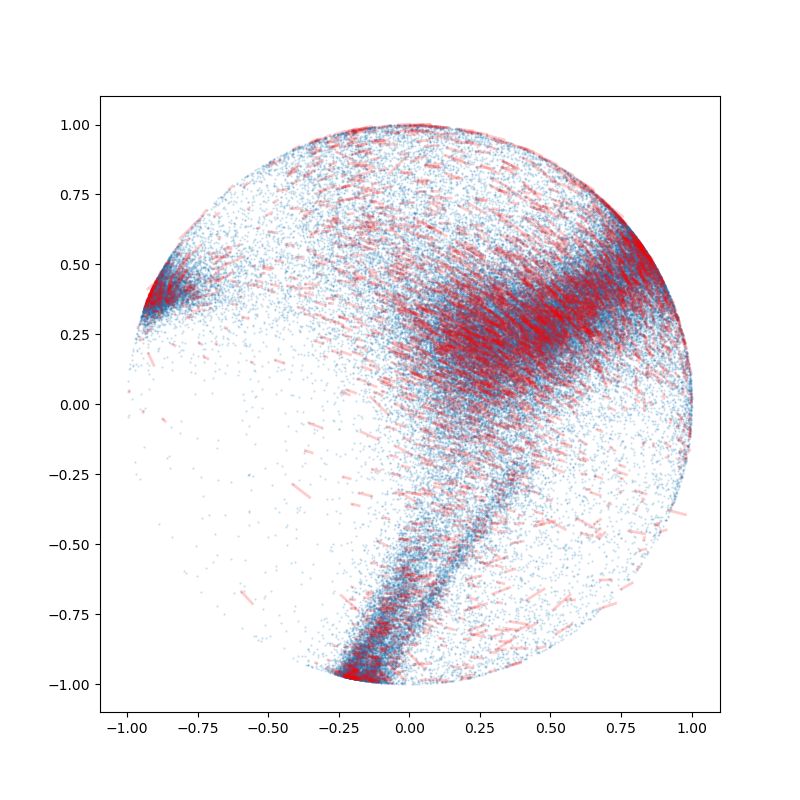

In [73]:
ix = np.random.rand(q3[:,0].shape[0]).flatten()<0.05
D = d3[ix,:]
Q = q3[ix,:]
Z = z3[ix,:]
W = 5*np.clip(D-Z,-0.012,0.012)

label = gene
sc = 1
nx = Q[:,0].shape[0]

plt.figure(figsize=(8,8))
plt.title(gene)
plt.plot(q3[:,0],q3[:,1],'.',markersize=1,alpha=0.25)
for n in range(nx):
    plt.plot([Q[n,0],Q[n,0]+W[n,0]],[Q[n,1],Q[n,1]+W[n,1]],'-r',lw=2,alpha=0.2)
plt.show()

(86024,)


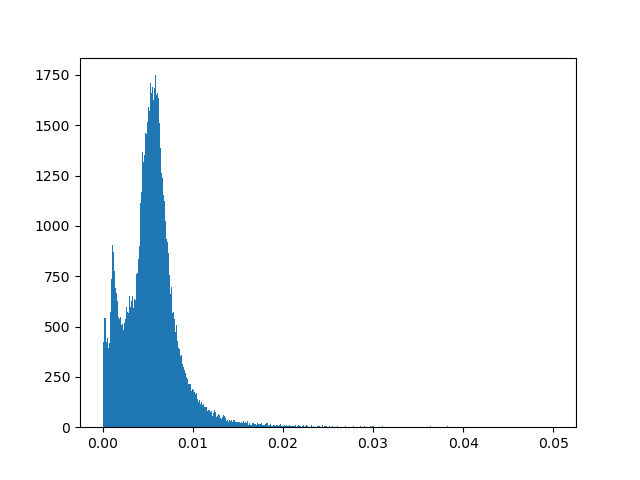

In [46]:
u3 = d3-z3
nu3 = np.linalg.norm(u3,axis=1)
print(nu3.shape)
bins = np.linspace(0,0.05,500)

plt.figure()
plt.hist(nu3,bins);
plt.show()

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

def showPolarSplit(dbl, zer, gene, frac=0.015):
    #-------------------------------------------------
    # Prepare the PCA data
    #-------------------------------------------------
    d3 = np.array(dbl[[gene+'_PC1', gene+'_PC2', gene+'_PC3']])
    z3 = np.array(zer[[gene+'_PC1', gene+'_PC2', gene+'_PC3']])
    q3 = np.array(dbl[['PC1', 'PC2', 'PC3']])

    #-------------------------------------------------
    # Apply rotation
    #-------------------------------------------------
    rot4 = R.from_euler('zyx', [0, -10, 10], degrees=True)
    q4 = rot4.apply(q3)
    d4 = rot4.apply(d3)
    z4 = rot4.apply(z3)

    #-------------------------------------------------
    # Identify North and South caps
    #-------------------------------------------------
    north_mask = q4[:,2] > 0.65
    south_mask = q4[:,2] < -0.55

    #-------------------------------------------------
    # Calculate displacement vectors
    #-------------------------------------------------
    scl = 1.0
    d1 = np.clip(scl*(d4 - q4), -0.1, 0.1)
    d2 = np.clip(scl*(z4 - q4), -0.1, 0.1)
    w2 = np.clip(q4 + d1, -1, 1)
    w0 = np.clip(q4 - d2, -1, 1)

    #-------------------------------------------------
    # Random subsample
    #-------------------------------------------------
    random_ix = np.random.rand(q3.shape[0]) < frac
    random_north = random_ix & north_mask
    random_south = random_ix & south_mask

    #-------------------------------------------------
    # Plot
    #-------------------------------------------------
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    for ax, mask, title in zip(axs, [north_mask, south_mask], ['North Cap', 'South Cap']):
        ax.set_title(f"{gene} - {title}", fontsize=12)

        # Background cells
        ax.plot(q4[mask,0], q4[mask,1], '.c', markersize=1, alpha=0.5)

        # Overlay vectors
        if title == 'North Cap':
            selected = random_north
            flip_z = False
        else:
            selected = random_south
            flip_z = True

        for n in np.where(selected)[0]:
            x0, y0 = q4[n,0], q4[n,1]
            xw0, yw0 = w0[n,0], w0[n,1]
            xw2, yw2 = w2[n,0], w2[n,1]
            ax.plot([x0, xw0], [y0, yw0], '-', color='#2222CC', lw=1, alpha=0.7)
            ax.plot([x0, xw2], [y0, yw2], '-', color='#CC2222', lw=1, alpha=0.7)
            ax.plot(x0, y0, '.k', markersize=2, alpha=0.5)

        ax.set_xlim(-1,1)
        ax.set_ylim(-1,1)

        # Remove x and y ticks and labels
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

        # Remove bounding box (spines)
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    plt.savefig(f'Plot/Polar_plot/polar_split_{gene}.png', dpi=600)
    plt.show()



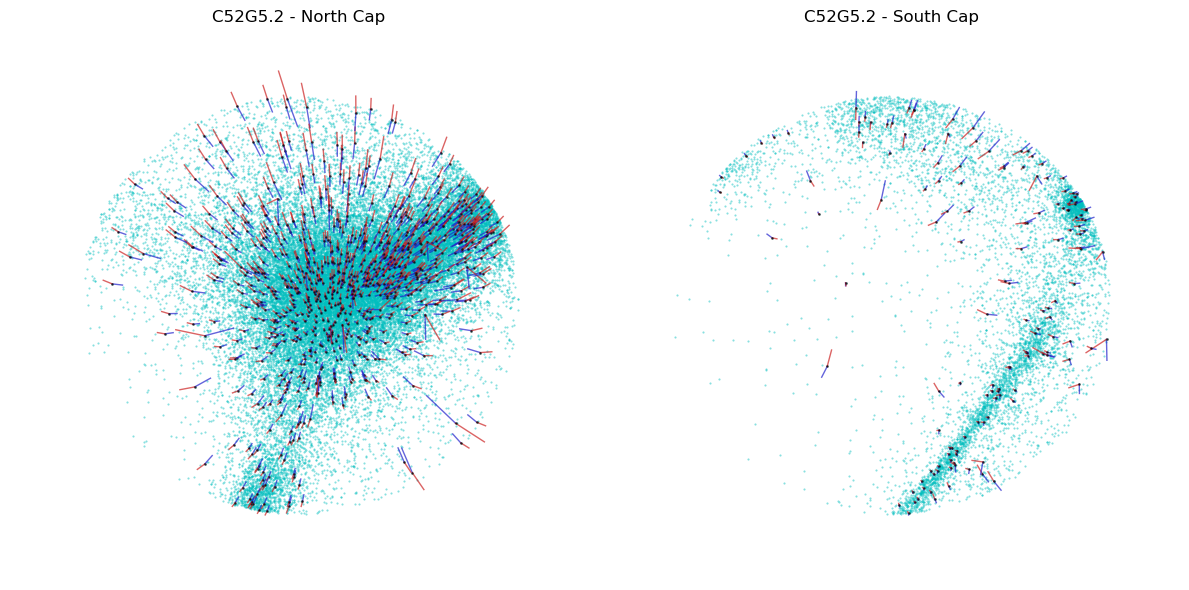

In [51]:
showPolarSplit(dbl, zer, genes[5], frac=0.02)

In [ ]:
for g in genes:
    showPolarSplit(dbl, zer, g, frac=0.02)

In [205]:
def showMask(dbl, zer, gene):
    #----------------------------------------------
    # 1. Load the rotated PCA data
    #----------------------------------------------
    d3 = np.array(dbl[[gene+'_PC1', gene+'_PC2', gene+'_PC3']])
    z3 = np.array(zer[[gene+'_PC1', gene+'_PC2', gene+'_PC3']])
    q3 = np.array(dbl[['PC1', 'PC2', 'PC3']])
    
    v3 = z3-q3
    w3 = d3-q3

    # --- after computing v3 & w3 ---
    norm_z = np.linalg.norm(v3, axis=1)
    norm_d = np.linalg.norm(w3, axis=1)
    
    scl = 1.0
    d1 = np.clip(scl * (d3 - q3), -0.1, 0.1)
    d2 = np.clip(scl * (z3 - q3), -0.1, 0.1)
    w2 = np.clip(q3 + d1, -1, 1)
    w0 = np.clip(q3 - d2, -1, 1)

    latO3, lonO3 = XYZ2LatLon(q3)
    latQ3, lonQ3 = XYZ2LatLon(q3)
    latW0, lonW0 = XYZ2LatLon(w0)
    latW2, lonW2 = XYZ2LatLon(w2)

    # Handle longitude wrap-around
    lonW0[lonW0 < -185] += 360
    lonW0[lonW0 > 185] -= 360
    lonW2[lonW2 < -185] += 360
    lonW2[lonW2 > 185] -= 360

    #---------------------------------------------------
    # 2. Plot
    #---------------------------------------------------
    plt.figure(figsize=(12,6))
    plt.title(gene)
    
    small_square = (norm_z <= 0.01) & (norm_d <= 0.01)
    above_diag = (norm_d > norm_z) & (~small_square)
    below_diag = (norm_d < norm_z) & (~small_square)

    # First plot the base cells with two colors
    plt.plot(lonO3[small_square], latO3[small_square], '.', color='black', markersize=2, alpha=0.7, label='Unperturbed')
    plt.plot(lonO3[above_diag], latO3[above_diag], '.', color='salmon', markersize=2, alpha=0.4, label='Doubling-sensitive')
    plt.plot(lonO3[below_diag], latO3[below_diag], '.', color='lightblue', markersize=2, alpha=0.4, label='Zeroing-sensitive')
    
    plt.xlim(-185, 185)
    plt.ylim(-90, 90)
    plt.xlabel('Longitude (°)', fontsize=10)
    plt.ylabel('Latitude (°)', fontsize=10)
    plt.legend(
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        fontsize=9,
        frameon=False
    )
    plt.tight_layout()
    #plt.show()
    plt.savefig(f'Plot/Mask_plot/latlon_masked_{gene}.png', dpi=600)
    plt.close()


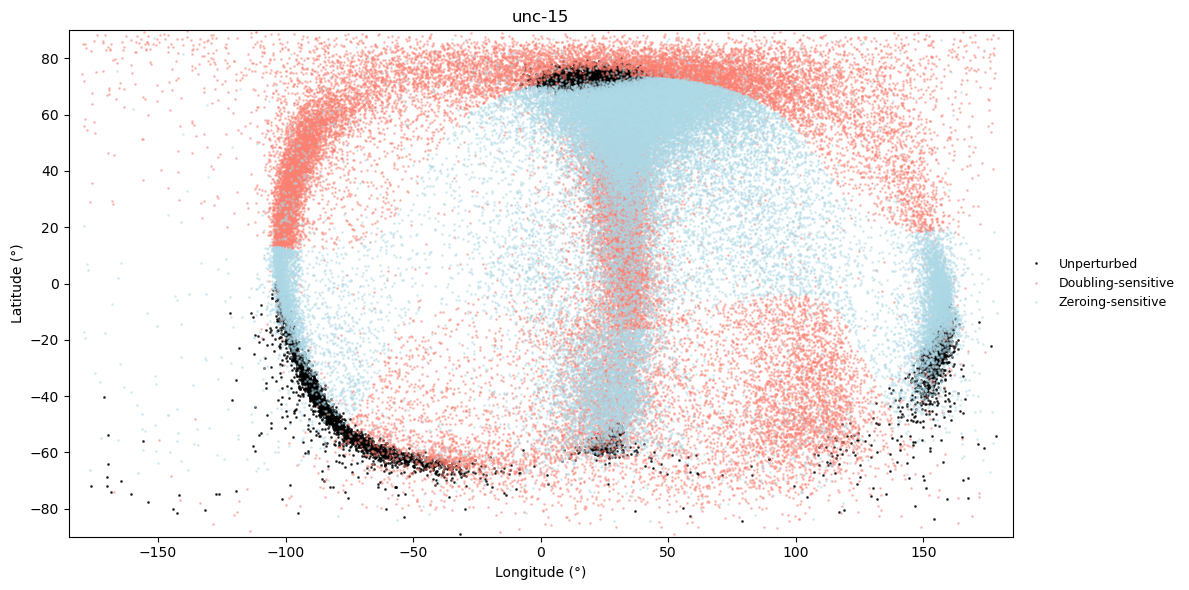

In [203]:
showMask(dbl, zer, gene)

In [ ]:
for g in genes:
    showMask(dbl,zer,g)

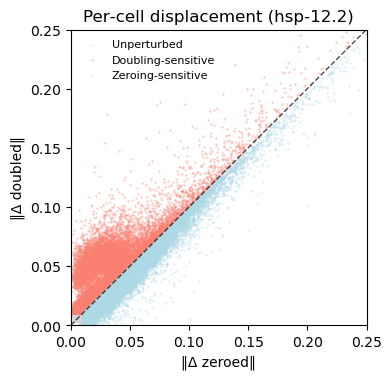

In [179]:
gene = 'hsp-12.2'
d3 = np.array(dbl[[gene+'_PC1',gene+'_PC2',gene+'_PC3']])
z3 = np.array(zer[[gene+'_PC1',gene+'_PC2',gene+'_PC3']])
q3 = np.array(dbl[['PC1','PC2','PC3']])

v3 = z3-q3
w3 = d3-q3

# --- after computing v3 & w3 ---
norm_z = np.linalg.norm(v3, axis=1)
norm_d = np.linalg.norm(w3, axis=1)

# --- Plot ---
fig, ax = plt.subplots(figsize=(4,4))

# 1) Define new masks
small_square = (norm_z <= 0.01) & (norm_d <= 0.01)
above_diag = (norm_d > norm_z) & (~small_square)
below_diag = (norm_d < norm_z) & (~small_square)

# 2) Scatter plot with different colors
ax.scatter(norm_z[small_square], norm_d[small_square], color='lightgrey', s=0.1, alpha=0.8, label='Unperturbed')
ax.scatter(norm_z[above_diag], norm_d[above_diag], color='salmon', s=0.1, alpha=0.8, label='Doubling-sensitive')
ax.scatter(norm_z[below_diag], norm_d[below_diag], color='lightblue', s=0.1, alpha=0.8, label='Zeroing-sensitive')

# 3) Plot the diagonal line
ax.plot([0, 0.25], [0, 0.25], 'k--', lw=1, alpha=0.7)

# 4) Set limits
ax.set_xlim(0, 0.25)
ax.set_ylim(0, 0.25)
ax.set_aspect('equal')

# 5) Labeling
ax.set_xlabel('‖Δ zeroed‖')
ax.set_ylabel('‖Δ doubled‖')
ax.set_title(f'Per‐cell displacement ({gene})')

# 
ax.legend(loc='upper left', frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig(f'Plot/scatter_masked_{gene}.png', dpi=600)
plt.show()

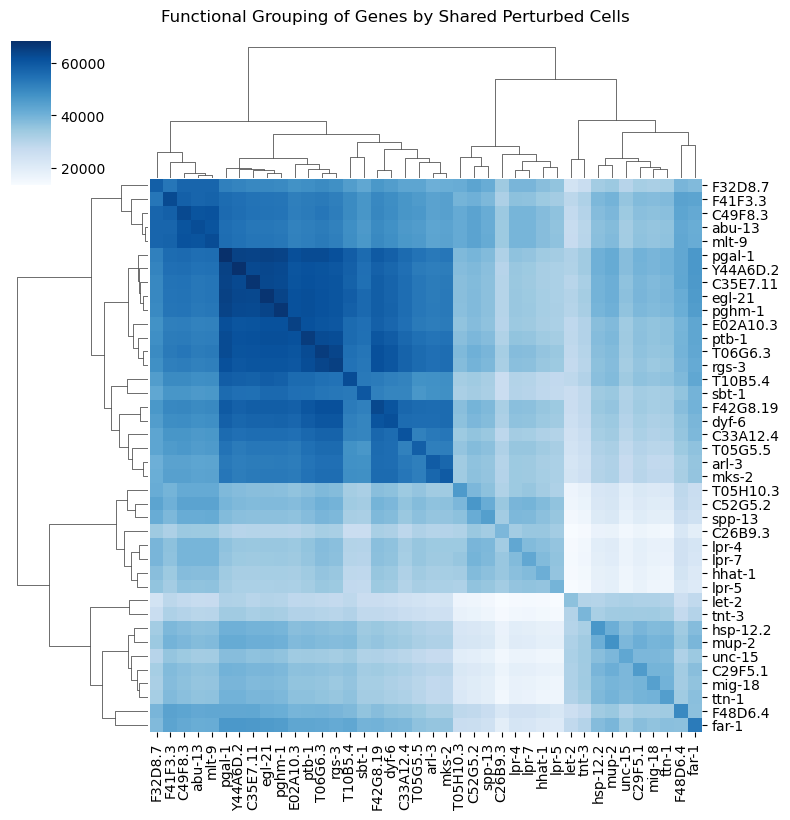

In [185]:
import seaborn as sns

gene_bitmaps = {}

for gene in genes:
    d3 = np.array(dbl[[gene+'_PC1',gene+'_PC2',gene+'_PC3']])
    z3 = np.array(zer[[gene+'_PC1',gene+'_PC2',gene+'_PC3']])
    q3 = np.array(dbl[['PC1','PC2','PC3']])

    v3 = z3-q3
    w3 = d3-q3

    # --- after computing v3 & w3 ---
    norm_z = np.linalg.norm(v3, axis=1)
    norm_d = np.linalg.norm(w3, axis=1)

    # 1) compute diagonal band masks (half‐width = 0.05)
    small_square = (norm_z <= 0.01) & (norm_d <= 0.01)
    above_diag = (norm_d > norm_z) & (~small_square)
    below_diag = (norm_d < norm_z) & (~small_square)

    # store the bitmap for this gene
    gene_bitmaps[gene] = below_diag

genes_list = sorted(gene_bitmaps.keys())
B = np.vstack([gene_bitmaps[g].astype(int) for g in genes_list])  # shape (n_genes, n_cells)

shared_counts = B @ B.T 

df_shared = pd.DataFrame(shared_counts, index=genes_list, columns=genes_list)

# Plot clustered heatmap
sns.clustermap(
    df_shared,
    method='average',    # hierarchical clustering method
    metric='euclidean',  # distance metric
    cmap='Blues',
    figsize=(8, 8),
    xticklabels=True,
    yticklabels=True
)
plt.suptitle('Functional Grouping of Genes by Shared Perturbed Cells', y=1.02)
plt.savefig("Plot/functional_grouping_below_diagonal.png", dpi=600)
plt.show()